In [1]:
## Phase 4: Unsupervised Classification


In [2]:
# imports

import pandas as pd  
from sklearn.ensemble import IsolationForest  
from sklearn.preprocessing import StandardScaler  
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# import data

df = pd.read_csv("../data/metrics.csv")

In [4]:
# feature construction

df['AstTO_Ratio'] = df['AvgAssists'] / (df['AvgTurnovers'])

In [5]:
unsupervised_features = [
    'AvgScoreDiff', 'WinPct', 'AvgPointsFor', 
    'AvgPointsAgainst', 'MasseyRankMean', 'AstTO_Ratio', 'AvgRebounds']

In [6]:
X_unsupervised = df[unsupervised_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsupervised)

In [7]:
isolation_forest = IsolationForest(n_estimators = 200, contamination = 0.05, random_state = 42)
isolation_forest.fit(X_scaled)
df['Isolation_Score'] = isolation_forest.decision_function(X_scaled)
df['Is_Anomaly'] = isolation_forest.predict(X_scaled)

In [8]:
top_anomalies = df.sort_values('Isolation_Score').head(10)
top_anomalies

,Season,TeamID,GamesPlayed,Wins,Losses,AvgPointsFor,AvgPointsAgainst,AvgScoreDiff,AvgAssists,AvgTurnovers,...,MasseyLatestDay,MaxTourneyDayNum,RoundReachedNum,RoundReached,MadeTournament,TourneyWins,TourneyLosses,AstTO_Ratio,Isolation_Score,Is_Anomaly
7797,2025,1290,29,1,28,52.448276,82.275862,-29.827586,7.896552,15.000000,...,133.0,NaN,NaN,NaN,0,0,0,0.526437,-0.128061,-1
6230,2021,1152,9,0,9,55.444444,88.666667,-33.222222,9.888889,14.555556,...,133.0,NaN,NaN,NaN,0,0,0,0.679389,-0.119426,-1
5585,2019,1211,33,30,3,88.848485,65.060606,23.787879,18.212121,10.363636,...,133.0,145.0,9.0,R9,1,3,1,1.757310,-0.103736,-1
1224,2006,1366,27,1,26,55.000000,82.777778,-27.777778,8.481481,20.481481,...,133.0,NaN,NaN,NaN,0,0,0,0.414105,-0.100537,-1
5085,2017,1417,33,29,4,90.363636,75.333333,15.030303,21.484848,11.545455,...,133.0,144.0,8.0,R8,1,2,1,1.860892,-0.100126,-1
7691,2025,1181,34,31,3,82.705882,61.911765,20.794118,16.764706,9.205882,...,133.0,152.0,11.0,R11,1,4,1,1.821086,-0.098368,-1
890,2005,1366,28,0,28,57.964286,81.214286,-23.250000,7.642857,19.607143,...,133.0,NaN,NaN,NaN,0,0,0,0.389800,-0.097967,-1
6237,2021,1159,15,14,1,86.333333,68.600000,17.733333,17.666667,9.800000,...,133.0,137.0,2.0,R2,1,0,1,1.802721,-0.093415,-1
1850,2008,1314,34,32,2,88.705882,72.735294,15.970588,16.735294,14.676471,...,133.0,152.0,10.0,R10,1,4,1,1.140281,-0.089132,-1
8109,2026,1237,30,5,25,80.866667,89.166667,-8.300000,18.933333,11.633333,...,NaN,NaN,NaN,NaN,0,0,0,1.627507,-0.088887,-1


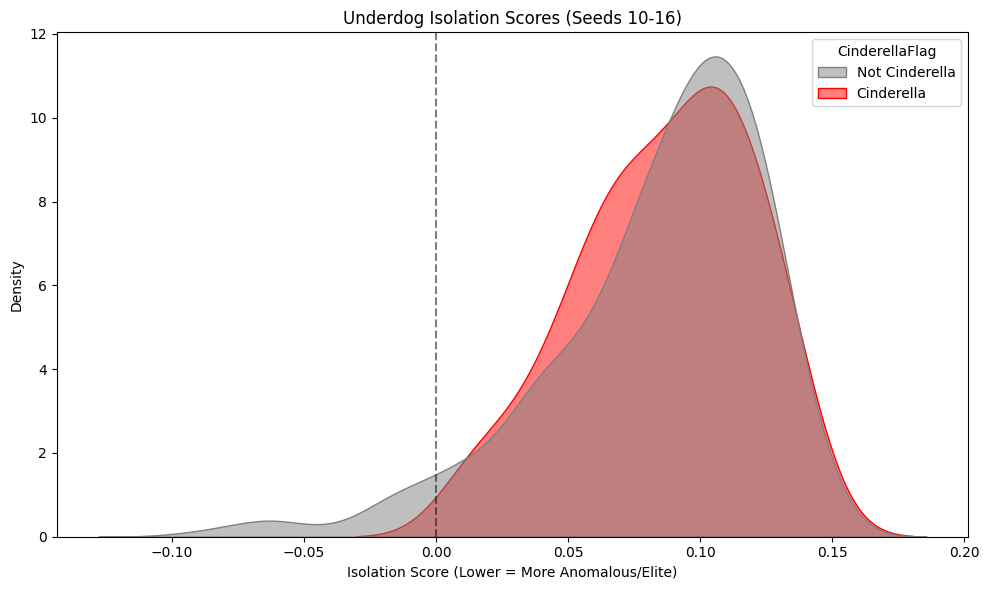

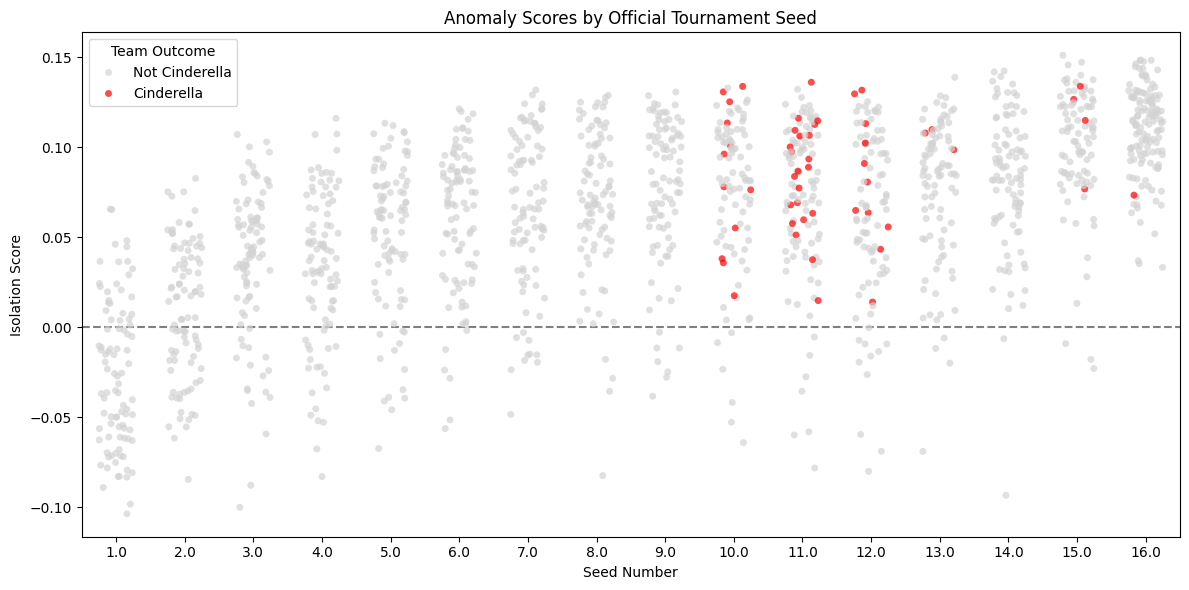

In [9]:
# We want to identify cinderella teams by looking for teams with at least 2 tournament wins while being a higher seed (10+)
df['CinderellaFlag'] = np.where(
    (df['SeedNum'] >= 10) & (df['TourneyWins'] >= 2),
    'Cinderella',
    'Not Cinderella'
)

tourney_teams = df[df['SeedNum'].notna()].copy()
underdogs = tourney_teams[tourney_teams['SeedNum'] >= 10]

# plot 1
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=underdogs, 
    x='Isolation_Score', 
    hue='CinderellaFlag', 
    fill=True, 
    common_norm=False, # Allows both curves to reach full height for easy comparison
    palette={'Not Cinderella': 'gray', 'Cinderella': 'red'},
    alpha=0.5
)
plt.title('Underdog Isolation Scores (Seeds 10-16)')
plt.xlabel('Isolation Score (Lower = More Anomalous/Elite)')
plt.ylabel('Density')
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# plot 2
plt.figure(figsize=(12, 6))
sns.stripplot(
    data=tourney_teams, 
    x='SeedNum', 
    y='Isolation_Score', 
    hue='CinderellaFlag',
    palette={'Not Cinderella': 'lightgray', 'Cinderella': 'red'},
    alpha=0.7,
    jitter=0.25,
    size=5
)
plt.title('Anomaly Scores by Official Tournament Seed')
plt.xlabel('Seed Number')
plt.ylabel('Isolation Score')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

# Fix the legend so it doesn't double-print
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title='Team Outcome')

plt.tight_layout()
plt.show()

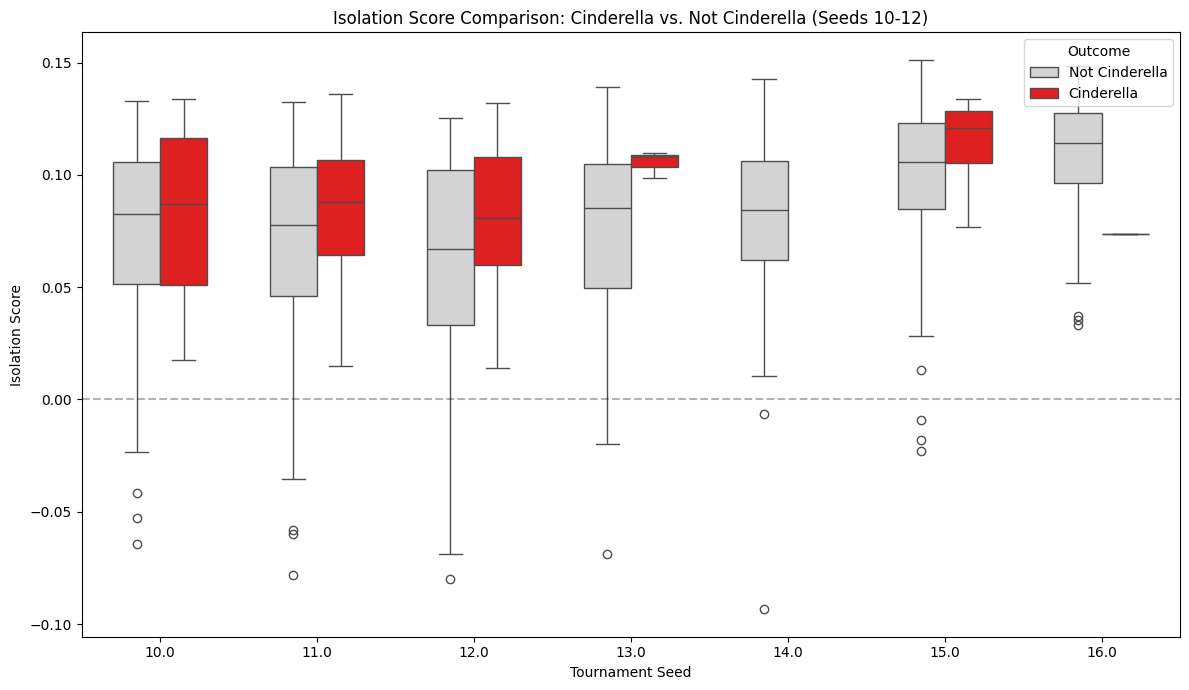

In [10]:
stratified_seeds = [10, 11, 12, 13, 14, 15, 16]
df_stratified = df[df['SeedNum'].isin(stratified_seeds)].copy()

# 2. Ensure CinderellaFlag is clearly defined
df_stratified['CinderellaFlag'] = np.where(
    (df_stratified['TourneyWins'] >= 2),
    'Cinderella',
    'Not Cinderella'
)

# 3. Create the stratified boxplot
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df_stratified,
    x='SeedNum',
    y='Isolation_Score',
    hue='CinderellaFlag',
    palette={'Not Cinderella': 'lightgray', 'Cinderella': 'red'},
    width=0.6
)

plt.title('Isolation Score Comparison: Cinderella vs. Not Cinderella (Seeds 10-12)')
plt.xlabel('Tournament Seed')
plt.ylabel('Isolation Score')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)

plt.legend(title='Outcome', loc='upper right')
plt.tight_layout()
plt.show()

In [11]:
# use the GMM

# apply mask to deal with NaNs
mask = ~np.isnan(X_scaled).any(axis=1)
X_cleaned = X_scaled[mask]
df_gmm = df.dropna(subset=unsupervised_features).copy()

n_clusters = 4
gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
gmm.fit(X_cleaned)

df_gmm['GMM_Cluster'] = gmm.predict(X_cleaned)

cluster_analysis = df_gmm.groupby(['GMM_Cluster', 'CinderellaFlag']).size().unstack(fill_value=0)
cluster_analysis['Total_Teams'] = cluster_analysis.sum(axis=1)

if 'Cinderella' in cluster_analysis.columns:
    cluster_analysis['Cinderella_Rate_%'] = (cluster_analysis['Cinderella'] / cluster_analysis['Total_Teams'] * 100).round(2)
    cluster_analysis['Capture_Share_%'] = (cluster_analysis['Cinderella'] / cluster_analysis['Cinderella'].sum() * 100).round(2)

print("--- GMM Cluster Analysis ---")
print(cluster_analysis)

cluster_means = df_gmm.groupby('GMM_Cluster')[unsupervised_features].mean()
print("\n--- Cluster Feature Means (Archetype Profiles) ---")
print(cluster_means.round(2))

df = df.merge(
    df_gmm[['Season', 'TeamID', 'GMM_Cluster']], 
    on=['Season', 'TeamID'], 
    how='left'
)

--- GMM Cluster Analysis ---
CinderellaFlag  Cinderella  Not Cinderella  Total_Teams  Cinderella_Rate_%  \
GMM_Cluster                                                                  
0                        4            2469         2473               0.16   
1                        0            1742         1742               0.00   
2                       45            1595         1640               2.74   
3                        4            1769         1773               0.23   

CinderellaFlag  Capture_Share_%  
GMM_Cluster                      
0                          7.55  
1                          0.00  
2                         84.91  
3                          7.55  

--- Cluster Feature Means (Archetype Profiles) ---
             AvgScoreDiff  WinPct  AvgPointsFor  AvgPointsAgainst  \
GMM_Cluster                                                         
0                   -0.00    0.50         67.93             67.93   
1                   -7.96    0.28      

In [12]:
# This shows that among potential cinderella teams, they are most likely to come from cluster 2.

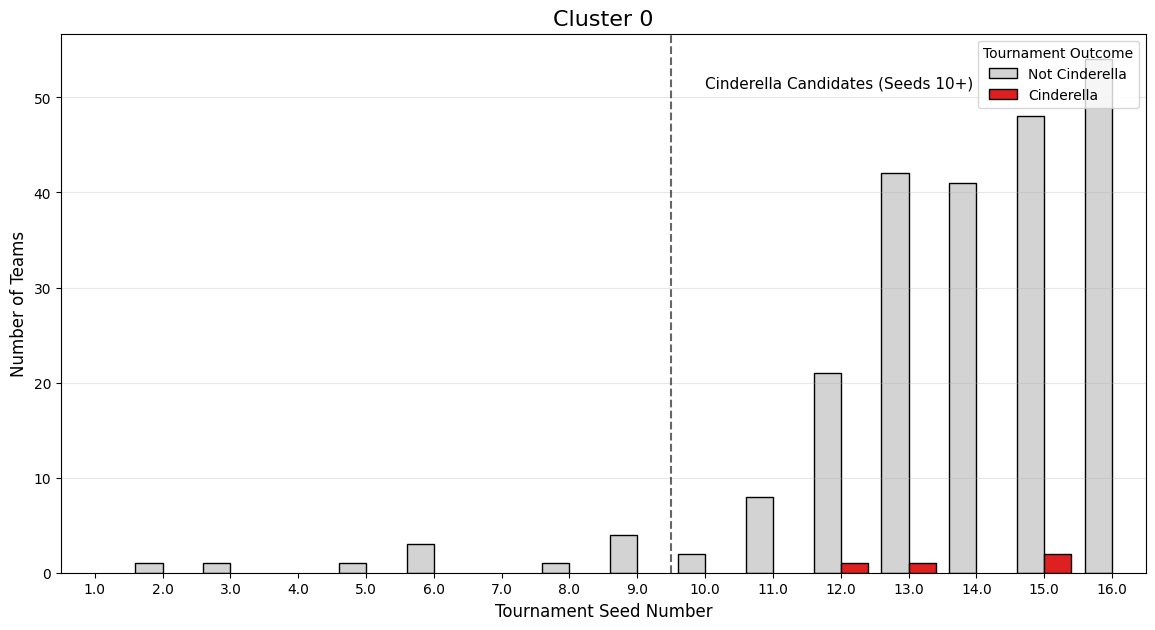

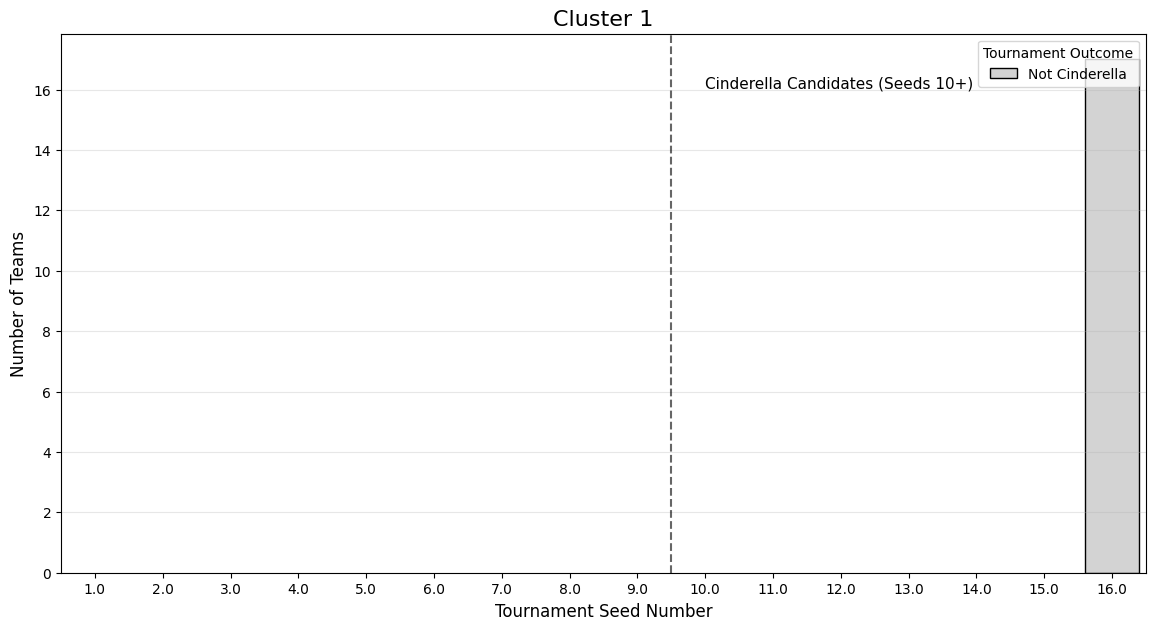

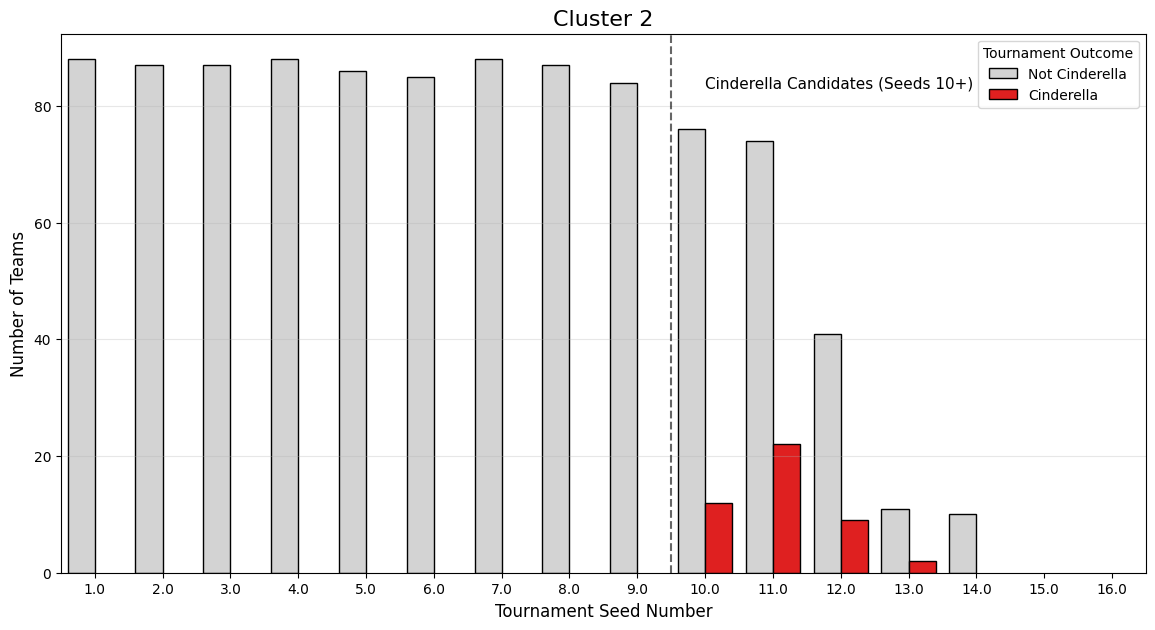

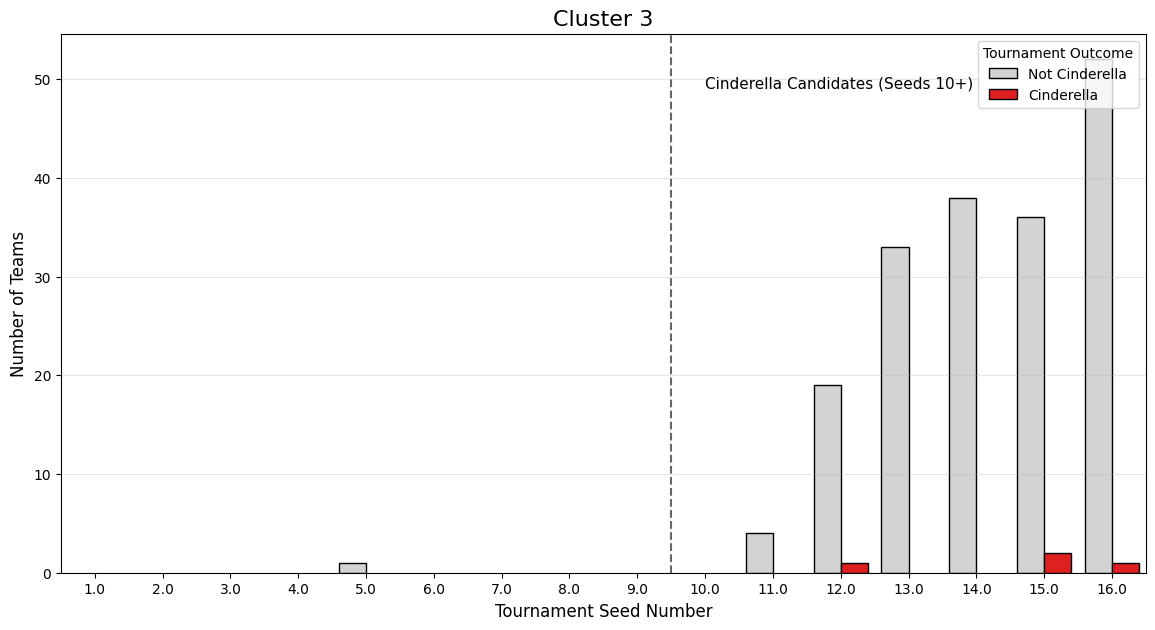

In [13]:
# divide clusters for plotting
tourney_cluster_0 = df[(df['GMM_Cluster'] == 0) & (df['SeedNum'].notna())].copy()
tourney_cluster_1 = df[(df['GMM_Cluster'] == 1) & (df['SeedNum'].notna())].copy()
tourney_cluster_2 = df[(df['GMM_Cluster'] == 2) & (df['SeedNum'].notna())].copy()
tourney_cluster_3 = df[(df['GMM_Cluster'] == 3) & (df['SeedNum'].notna())].copy()


seed_order = sorted(df['SeedNum'].dropna().unique())

# --- Cluster 0 ---

plt.figure(figsize=(14, 7))

sns.countplot(
    data=tourney_cluster_0, 
    x='SeedNum', 
    hue='CinderellaFlag',
    order=seed_order,  # LOCKS THE X-AXIS
    palette={'Cinderella': 'red', 'Not Cinderella': 'lightgray'},
    edgecolor='black'
)

plt.title('Cluster 0', fontsize=16)
plt.xlabel('Tournament Seed Number', fontsize=12)
plt.ylabel('Number of Teams', fontsize=12)
plt.axvline(x=8.5, color='black', linestyle='--', alpha=0.6)
plt.text(9, plt.gca().get_ylim()[1]*0.9, 'Cinderella Candidates (Seeds 10+)', fontsize=11, color='black')
plt.legend(title='Tournament Outcome', loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()

# --- Cluster 1 ---

plt.figure(figsize=(14, 7))

sns.countplot(
    data=tourney_cluster_1, 
    x='SeedNum', 
    hue='CinderellaFlag',
    order=seed_order,  # LOCKS THE X-AXIS
    palette={'Cinderella': 'red', 'Not Cinderella': 'lightgray'},
    edgecolor='black'
)

plt.title('Cluster 1', fontsize=16)
plt.xlabel('Tournament Seed Number', fontsize=12)
plt.ylabel('Number of Teams', fontsize=12)
plt.axvline(x=8.5, color='black', linestyle='--', alpha=0.6)
plt.text(9, plt.gca().get_ylim()[1]*0.9, 'Cinderella Candidates (Seeds 10+)', fontsize=11, color='black')
plt.legend(title='Tournament Outcome', loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()

# --- Cluster 2 ---

plt.figure(figsize=(14, 7))

sns.countplot(
    data=tourney_cluster_2, 
    x='SeedNum', 
    hue='CinderellaFlag',
    order=seed_order,  # LOCKS THE X-AXIS
    palette={'Cinderella': 'red', 'Not Cinderella': 'lightgray'},
    edgecolor='black'
)

plt.title('Cluster 2', fontsize=16)
plt.xlabel('Tournament Seed Number', fontsize=12)
plt.ylabel('Number of Teams', fontsize=12)
plt.axvline(x=8.5, color='black', linestyle='--', alpha=0.6)
plt.text(9, plt.gca().get_ylim()[1]*0.9, 'Cinderella Candidates (Seeds 10+)', fontsize=11, color='black')
plt.legend(title='Tournament Outcome', loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()

# --- Cluster 3 ---

plt.figure(figsize=(14, 7))

sns.countplot(
    data=tourney_cluster_3, 
    x='SeedNum', 
    hue='CinderellaFlag',
    order=seed_order,  # LOCKS THE X-AXIS
    palette={'Cinderella': 'red', 'Not Cinderella': 'lightgray'},
    edgecolor='black'
)

plt.title('Cluster 3', fontsize=16)
plt.xlabel('Tournament Seed Number', fontsize=12)
plt.ylabel('Number of Teams', fontsize=12)
plt.axvline(x=8.5, color='black', linestyle='--', alpha=0.6)
plt.text(9, plt.gca().get_ylim()[1]*0.9, 'Cinderella Candidates (Seeds 10+)', fontsize=11, color='black')
plt.legend(title='Tournament Outcome', loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [14]:
import joblib
import os

print("Exporting Unsupervised GMM Model...")

# Ensure the models directory exists
os.makedirs('../models', exist_ok=True)

# Save the scaler and the GMM model
joblib.dump(scaler, '../models/unsupervised_scaler.pkl')
joblib.dump(gmm, '../models/gmm_cluster_model.pkl')

print("Success! GMM and Scaler saved to the /models folder.")

Exporting Unsupervised GMM Model...
Success! GMM and Scaler saved to the /models folder.


### GMM Cluster Interpretation: The "Under-Seeded" Phenom

The Gaussian Mixture Model (GMM) successfully categorized all NCAA teams into four distinct archetypes. By overlaying our Cinderella data, we gain two major insights:

**Cluster 2**
    This cluster is primarily populated by high seeded tournament teams. The fact that nearly **85% of historical Cinderellas** fall into this group proves that many "underdog" runs are not flukes. Instead, these teams are mathematically as strong as higher seeds but were simply **under-seeded** by the selection committee. 

**Cluster 3**
    This group represents teams with unusually high pace or statistical variance. While they are not as consistent as Cluster 2, they possess the explosive scoring potential to have "hot games." These teams represent the subset of Cinderellas that win through high-risk, high-reward playstyles rather than pure statistical dominance.

**Key Finding:** Cinderella teams are almost exclusively found in Clusters 2 and 3. This suggests that certain archetypes of teams are more likely to be cinderella's than others.

### Visualization Takeaways: The Indistinguishable Cinderella

Based on the anomaly score distributions, we observed the following key findings:

**Indistinguishable Profiles:** Cinderella teams are largely indistinguishable from non-Cinderella teams. They consistently fall within the same distribution and, based upon our unsupervised regular-season features, do not appear mathematically different from standard early-exit teams.
**Refuting the Hypothesis:** We initially assumed that Cinderella teams would need to be more negative-leaning (highly anomalous) to pull off an upset. However, the data shows that historical Cinderellas tended to have Isolation Scores spread across the standard distribution of their respective seeds. 
**Lack of Variance:** Cinderella teams did not stand out significantly as statistical outliers compared to other members of their seed line. 